In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import quantile_forest as qrf

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

from scipy.stats import binom

In [5]:
X_train = np.load('../X_train_final.npy')
y_train = np.load('../y_train_final.npy')

X_test = np.load('../X_test_final.npy')
y_test = np.load('../y_test_final.npy')

with open('../output/best-feats-low.pkl', 'rb+') as f:
    best_cog = pickle.load(f)
with open('../output/best-feats-high-qrf.pkl', 'rb+') as f:
    best_dif = pickle.load(f)

BEST_PARAMS = {
    'n_estimators': 128,
    'max_depth': 16
}

X_train_cog = X_train[:, 0, best_cog]
y_train_cog = y_train[:, 0, 0]

X_train_dif = X_train[:, 0, best_dif]
y_train_dif = y_train[:, 0, 1]

qrf_model_cog = qrf.RandomForestQuantileRegressor(
    n_jobs=-1,
    verbose=True,
    **BEST_PARAMS
)

qrf_model_cog.fit(X_train_cog, y_train_cog)

qrf_model_dif = qrf.RandomForestQuantileRegressor(
    n_jobs=-1,
    verbose=True,
    **BEST_PARAMS
)

qrf_model_dif.fit(X_train_dif, y_train_dif)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.9s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:   14.3s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:    0.2s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    4.1s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:   15.5s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:    0.1s finished


,n_estimators,128
,default_quantiles,0.5
,criterion,'squared_error'
,max_depth,16
,min_samples_split,2
,min_samples_leaf,1
,max_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [6]:
mmsis = np.load('../all-mmsis-test.npy', allow_pickle=True)
days = np.load('../all-days-test.npy', allow_pickle=True)

val_mmsis = np.load('../val-mmsis-test.npy', allow_pickle=True)
val_days = np.load('../val-days-test.npy', allow_pickle=True)

timestamps_dict = np.load('../timestamps-dict.npy', allow_pickle=True)

In [8]:
assert len(mmsis) == y_test.shape[0]

In [9]:
X_test_cog = X_test[:, 0, best_cog]
y_test_cog = y_test[:, 0, 0]

X_test_dif = X_test[:, 0, best_dif]
y_test_dif = y_test[:, 0, 1]

In [10]:
y_pred_cog = qrf_model_cog.predict(X_test_cog, quantiles=[0.025, 0.975])
y_low_cog, y_high_cog = y_pred_cog[:, 0], y_pred_cog[:, 1]

y_pred_dif = qrf_model_cog.predict(X_test_dif, quantiles=[0.025, 0.975])
y_low_dif, y_high_dif = y_pred_cog[:, 0], y_pred_cog[:, 1]

mistake_mask_cog = (
    (y_test_cog < y_low_cog) |
    (y_test_cog > y_high_cog)
)

mistake_mask_dif = (
    (y_test_dif < y_low_dif) |
    (y_test_dif > y_high_dif)
)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 128 out of 128 | elapsed:    0.1s finished


In [12]:
mistake_dict = {}
for ix, (mmsi, day) in enumerate( zip( mmsis, days ) ):

    if (mmsi, day) not in mistake_dict:
        mistake_dict[ (mmsi,day) ] = [ mistake_mask_dif[ix] ]
    else:
        mistake_dict[ (mmsi,day) ].append( mistake_mask_dif[ix] )

In [57]:
error_indices = {}
mmsi_check = {}

for (m,d), mask in mistake_dict.items():

    n = len(mask)
    indices = np.array( range(n) )
    error_ix = indices[mask]

    thresh = binom.ppf(0.999, n, 1-0.956)

    if len(error_ix) > thresh:
        error_indices[m,d] = error_ix
        mmsi_check[m] = 1

In [58]:
len( mmsi_check.keys() )

232

In [61]:
len( np.unique(mmsis) )

544

In [16]:
import pandas as pd

In [ ]:
df = pd.read_csv('../data/df-prepared.csv')

In [50]:
grouped = df.groupby(by=['MMSI', 'day'])
error_data = {}

for (mmsi, day), data in grouped:
    if (mmsi, day) in error_indices:
        indices = error_indices[(mmsi, day)]
        error_data[(mmsi, day)] = data.iloc[indices, :]

In [126]:
def box_plot_anomalies(error_data, df, col, vertimas):
    values = []
    for (_, _), data in error_data.items():
        values.extend( list(data[col].values) )

    _, ax = plt.subplots()
    ax.violinplot([values, df[col]], vert=False)
    ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)
    ax.set_xlim((df[col].min(), df[col].max()))
    ax.set_xlabel(vertimas, fontsize=18)
    ax.set_title(vertimas)
    ax.tick_params(labelsize=14)
    plt.tight_layout()
    plt.savefig(f'comparison-qrf-{col}.png', dpi=750)
    plt.show()

In [127]:
df.columns

Index(['SOG', 'COG', 'Cargo type', 'Width', 'Length', 'currentSpeed', 'gust',
       'swellHeight', 'waveHeight', 'windSpeed', 'COG_vec_x', 'COG_vec_y',
       'currentDirection_vec_x', 'currentDirection_vec_y',
       'swellDirection_vec_x', 'swellDirection_vec_y', 'waveDirection_vec_x',
       'waveDirection_vec_y', 'windDirection_vec_x', 'windDirection_vec_y',
       'COG-dif', 'delta_dif', 'MMSI', 'day'],
      dtype='str')

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


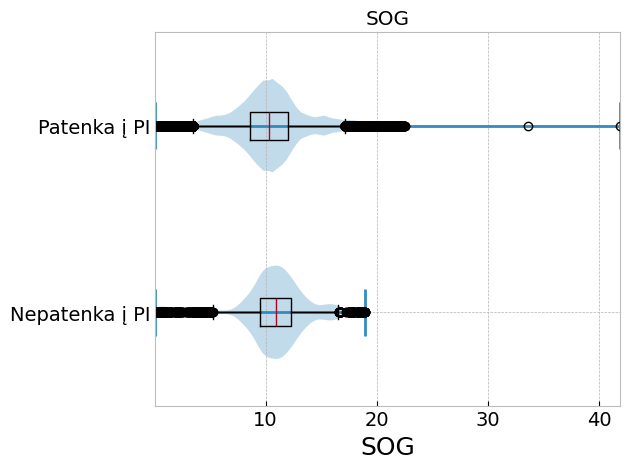

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


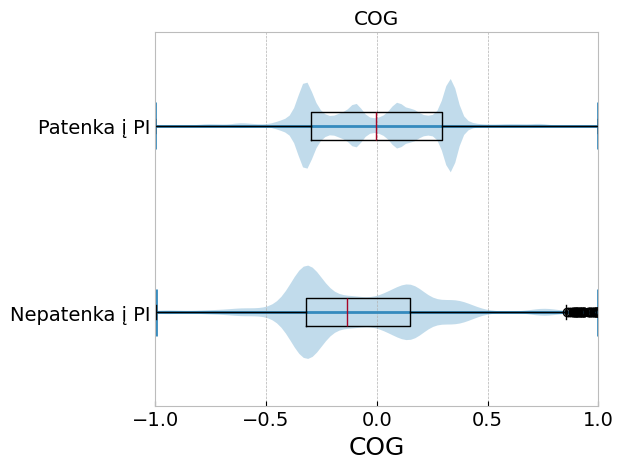

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


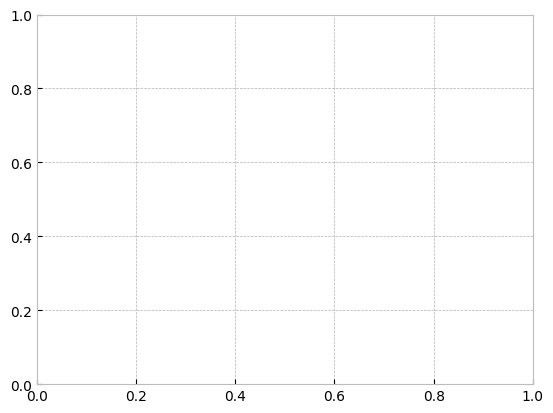

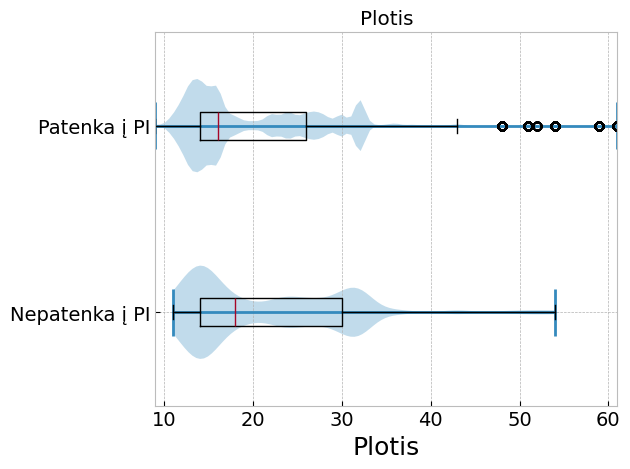

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


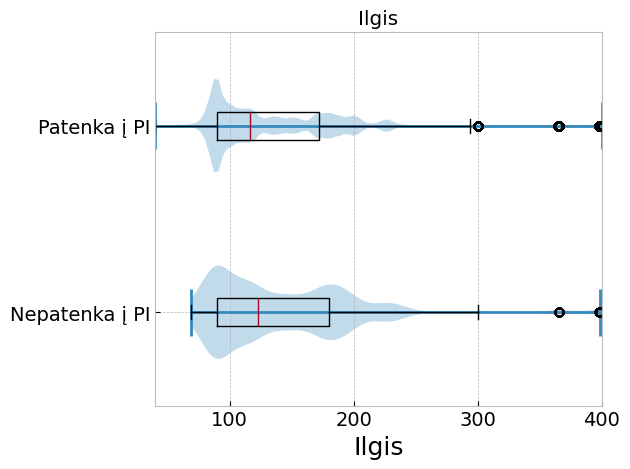

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


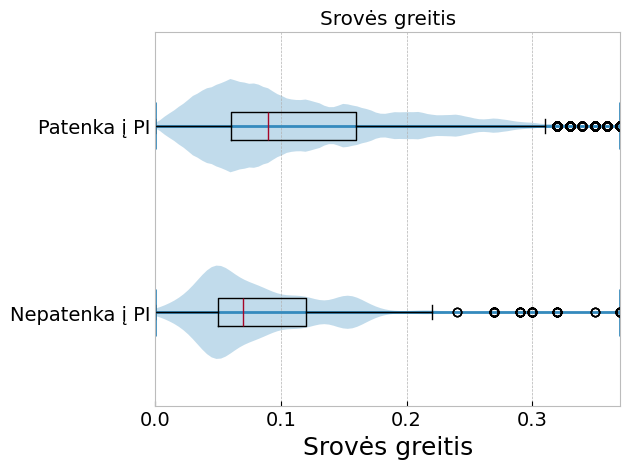

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


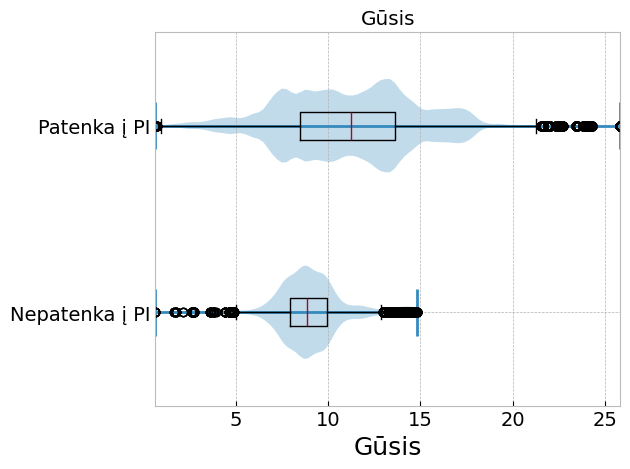

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


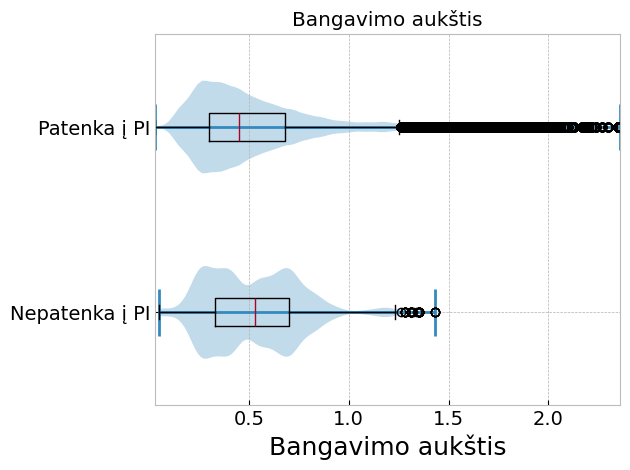

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


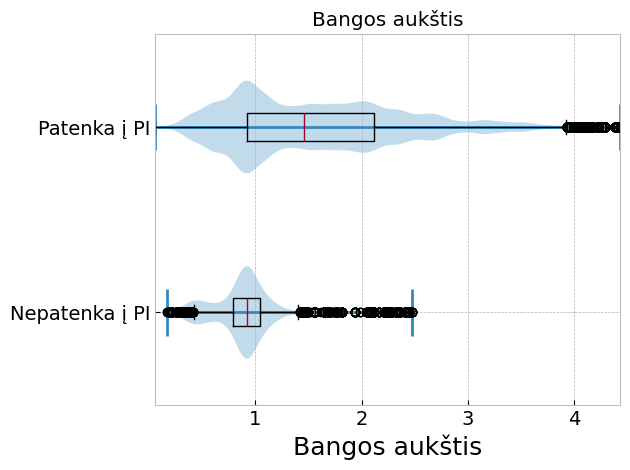

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


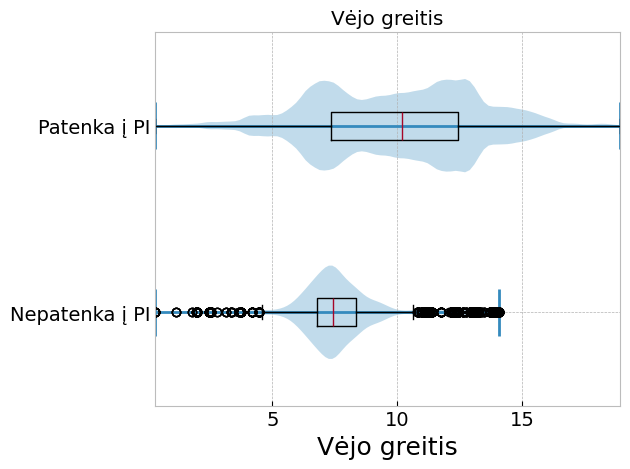

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


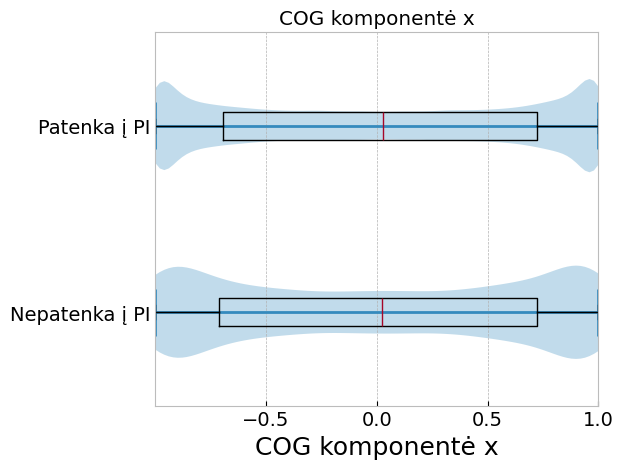

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


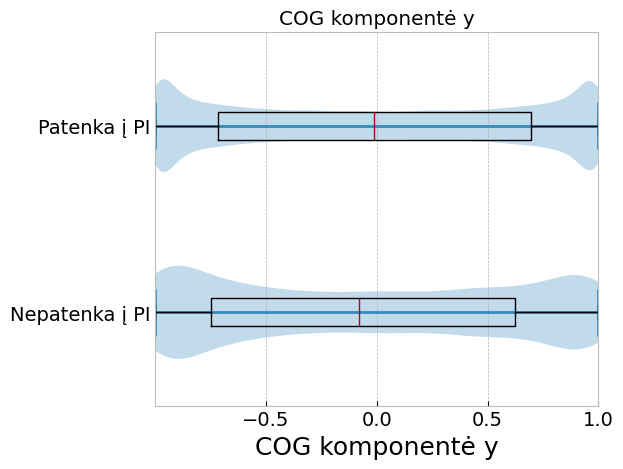

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


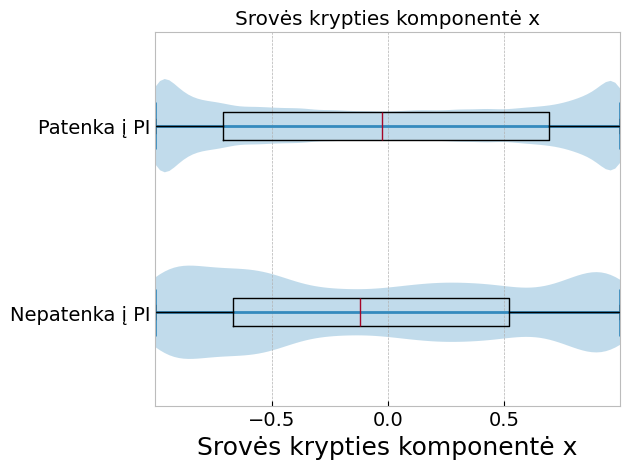

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


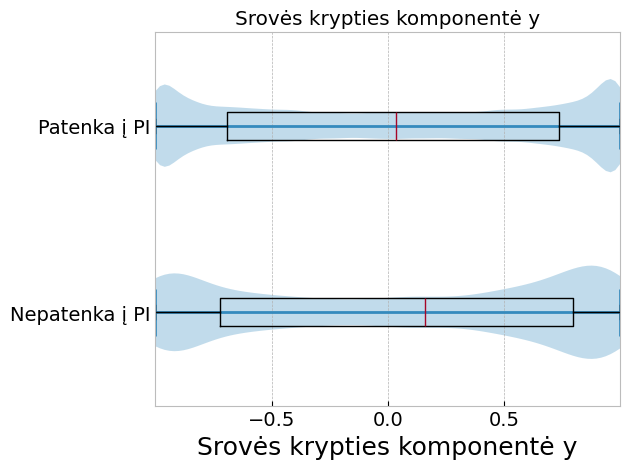

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


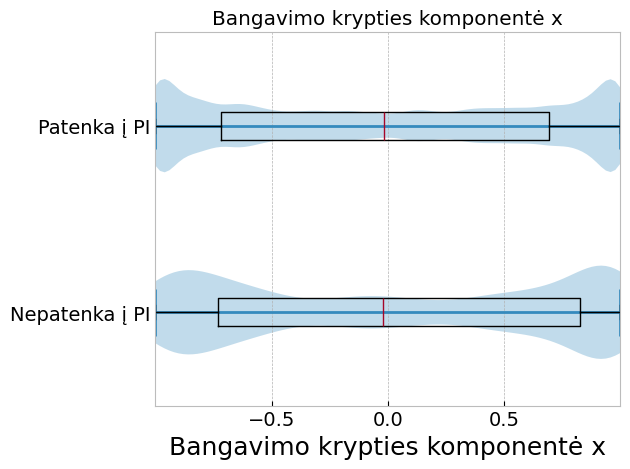

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


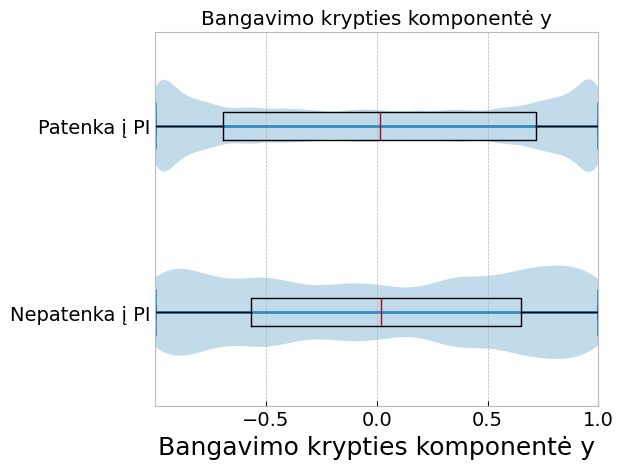

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


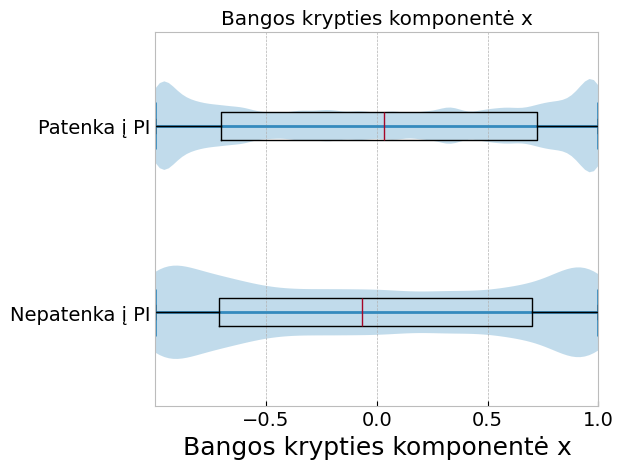

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


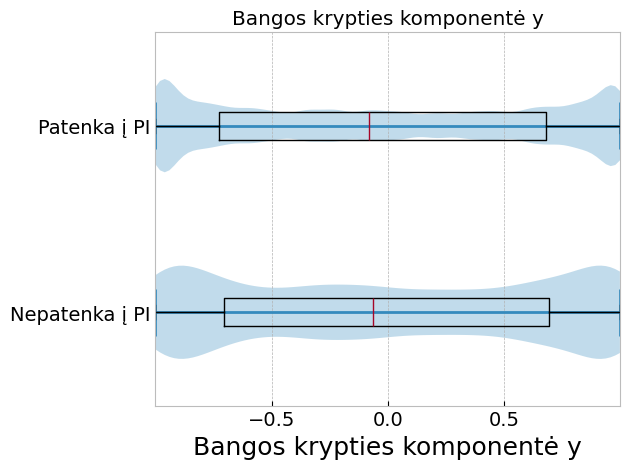

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


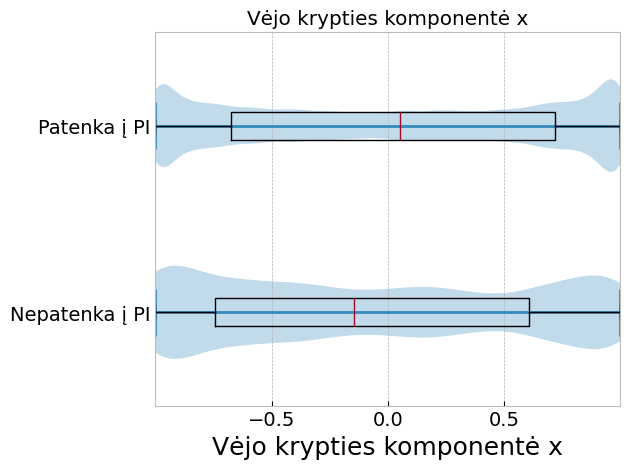

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


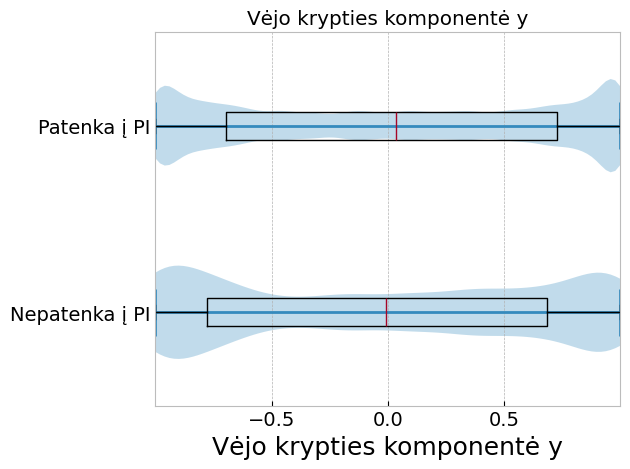

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


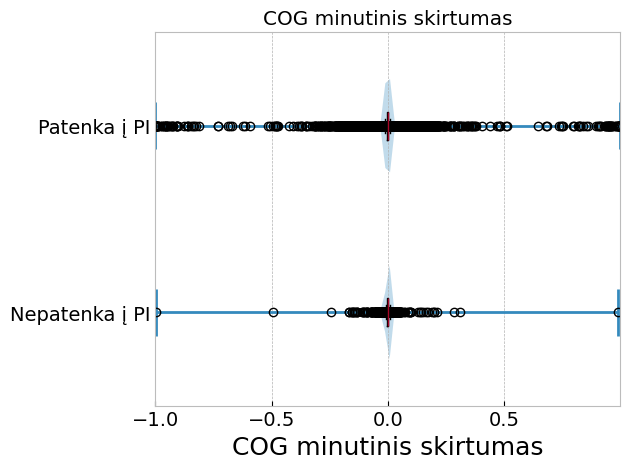

/tmp/ipykernel_4942/2069574318.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([values, df[col]], labels=['Nepatenka į PI', 'Patenka į PI'], vert=False)


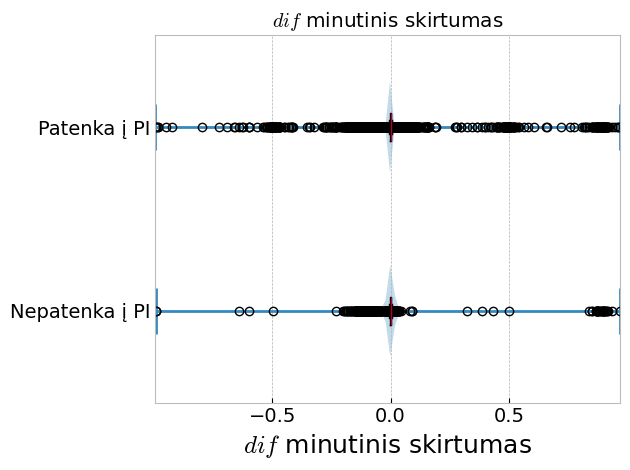

In [130]:
vertimai = {
"SOG": "SOG",
"COG": "COG",
"Cargo type": "Krovinių tipas",
"Width": "Plotis",
"Length": "Ilgis",
"currentSpeed": "Srovės greitis",
"gust": "Gūsis",
"swellHeight": "Giluminių bangų aukštis",
"waveHeight": "Bangų aukštis",
"windSpeed": "Vėjo greitis",
"COG_vec_x": "COG komponentė x",
"COG_vec_y": "COG komponentė y",
"currentDirection_vec_x": "Srovės krypties komponentė x",
"currentDirection_vec_y": "Srovės krypties komponentė y",
"swellDirection_vec_x": "Bangavimo krypties komponentė x",
"swellDirection_vec_y": "Bangavimo krypties komponentė y",
"waveDirection_vec_x": "Bangos krypties komponentė x",
"waveDirection_vec_y": "Bangos krypties komponentė y",
"windDirection_vec_x": "Vėjo krypties komponentė x",
"windDirection_vec_y": "Vėjo krypties komponentė y",
"COG-dif": "COG minutinis skirtumas",
"delta_dif": "$dif$ minutinis skirtumas"
}

for col, vertimas in vertimai.items():
    try:
        box_plot_anomalies(error_data, df, col, vertimas)
    except:
        
        continue